In [ ]:
import pandas as pd
import os
from dotenv import load_dotenv
from azure.storage.filedatalake import DataLakeServiceClient
import urllib
from sqlalchemy import create_engine
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="darkgrid")

ValueError: style must be one of white, dark, whitegrid, darkgrid, ticks

In [27]:
project_root = Path.cwd().parent / "scripts" 
env_path = project_root / ".env"
load_dotenv(dotenv_path=env_path)

SQL_SERVER_NAME = os.getenv('AZURE_SQL_SERVER')
SQL_DATABASE = os.getenv('AZURE_SQL_DATABASE')
SQL_USER = os.getenv('AZURE_SQL_USER')
SQL_PASSWORD = os.getenv('AZURE_SQL_PASSWORD')

# Build connection
connection_string = (
    f"DRIVER={{ODBC Driver 18 for SQL Server}};"
    f"SERVER={SQL_SERVER_NAME};"
    f"DATABASE={SQL_DATABASE};"
    f"UID={SQL_USER};"
    f"PWD={SQL_PASSWORD};"
    f"Encrypt=yes;"
    f"TrustServerCertificate=no;"
)

params = urllib.parse.quote_plus(connection_string)
engine = create_engine(f"mssql+pyodbc:///?odbc_connect={params}")

In [35]:
contract_kpi_df = pd.read_sql("Select * from vw_churn_by_contract_kpi", engine)
payment_method_kpi_df = pd.read_sql("Select * from vw_churn_by_payment_method_kpi", engine)
tenure_band_kpi_df = pd.read_sql("Select * from vw_churn_by_tenure_band_kpi", engine)
high_risk_cust_kpi_df = pd.read_sql("Select * from vw_high_risk_customers", engine)
overall_churn_kpi_df = pd.read_sql("Select * from vw_overall_churn_kpis", engine)

,loyaltyid,customer_id,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,...,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,318537,7590-VHVEG,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,152148,5575-GNVDE,No,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,326527,3668-QPYBK,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,845894,7795-CFOCW,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,503388,9237-HQITU,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [37]:
contract_kpi_df.head()

,contract_name,customer_count,churned_count,churn_rate_percentage
0,Month-to-month,3875.0,1655.0,42.71
1,One year,1473.0,166.0,11.27
2,Two year,1695.0,48.0,2.83


In [38]:
payment_method_kpi_df.head()

,payment_method,customer_count,churned_count,churn_rate_percentage
0,Bank transfer (automatic),1544.0,258.0,16.71
1,Credit card (automatic),1522.0,232.0,15.24
2,Electronic check,2365.0,1071.0,45.29
3,Mailed check,1612.0,308.0,19.11


In [39]:
tenure_band_kpi_df.head()

,tenure_band,customer_count,churned_count,churn_rate_percentage
0,new customers,2186.0,1037.0,47.44
1,developing customers,1024.0,294.0,28.71
2,established customers,1594.0,325.0,20.39
3,long-term customers,2239.0,213.0,9.51


In [40]:
high_risk_cust_kpi_df.head()

,customer_id,tenure,contract,monthly_charges,churn_score,churn_category,revenue_rank
0,8199-ZLLSA,67,One year,118.35,91,Competitor,1
1,2889-FPWRM,72,One year,117.80,91,Competitor,2
2,2302-ANTDP,48,Month-to-month,117.45,67,Competitor,3
3,9053-JZFKV,67,Two year,116.20,82,Other,4
4,1444-VVSGW,70,One year,115.65,91,Dissatisfaction,5


In [41]:
overall_churn_kpi_df.head()

,total_customers,churned_customers,retained_customers,churn_rate_pct,total_revenue_at_risk,avg_cltv_churned,avg_cltv_retained
0,7043,1869.0,5174.0,26.54,139130.85,4149.41,4490.92


### Visualizations

Text(0.5, 1.0, '')

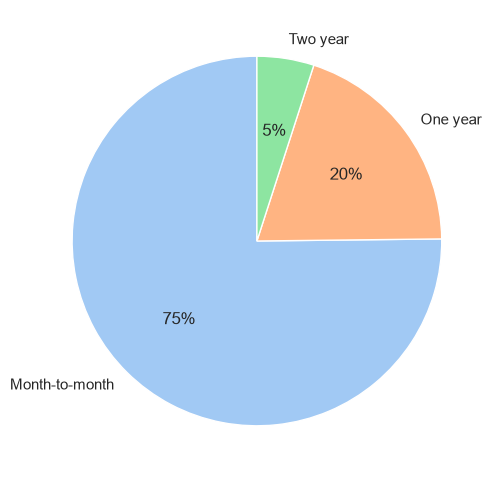

In [57]:
data = contract_kpi_df["churn_rate_percentage"]
labels = contract_kpi_df["contract_name"]

# 2. Select a Seaborn color palette (e.g., 'pastel', 'deep', 'muted', 'Set2')
colors = sns.color_palette('pastel')[0:len(data)]

# 3. Create the pie chart using Matplotlib
plt.figure(figsize=(6, 6))
plt.pie(
    data, 
    labels=labels, 
    colors=colors, 
    autopct='%.0f%%',  # Formats percentages inside slices
    startangle=90      # Rotates chart to start at 12 o'clock
)

# 4. Display the chart
plt.title('')

<Axes: xlabel='contract_name', ylabel='churn_rate_percentage'>

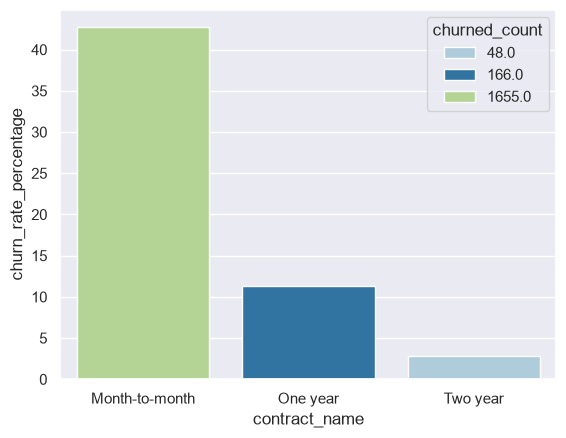

In [ ]:
sns.barplot(data=contract_kpi_df, x=contract_kpi_df["contract_name"], y=contract_kpi_df["churn_rate_percentage"], hue=contract_kpi_df["churned_count"], palette="Paired")

C:\Users\omson\AppData\Local\Temp\ipykernel_51940\284268553.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=contract_kpi_df, x=contract_kpi_df["contract_name"], y=contract_kpi_df["churn_rate_percentage"], palette="Paired")


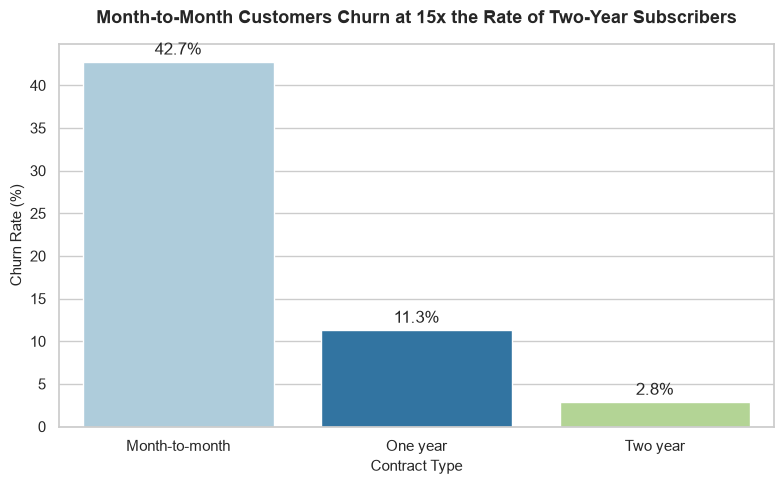

In [73]:
fig, ax = plt.subplots(figsize=(8, 5))

# Draw the bar chart — no hue, pick one strong color
sns.barplot(data=contract_kpi_df, x=contract_kpi_df["contract_name"], y=contract_kpi_df["churn_rate_percentage"], palette="Paired")

# Add value labels on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

# Title that states the business insight
ax.set_title("Month-to-Month Customers Churn at 15x the Rate of Two-Year Subscribers", 
             fontsize=13, fontweight='bold', pad=15)

ax.set_xlabel("Contract Type", fontsize=11)
ax.set_ylabel("Churn Rate (%)", fontsize=11)

sns.set_style("whitegrid")
plt.tight_layout()
plt.savefig("../outputs/churn_by_contract.png", dpi=150, bbox_inches='tight')
plt.show()